<a href="https://colab.research.google.com/github/defneulku-hub/DSA210-project-Irmak-Defne-lk-/blob/main/dsa210_eda_hyp_UPDATED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

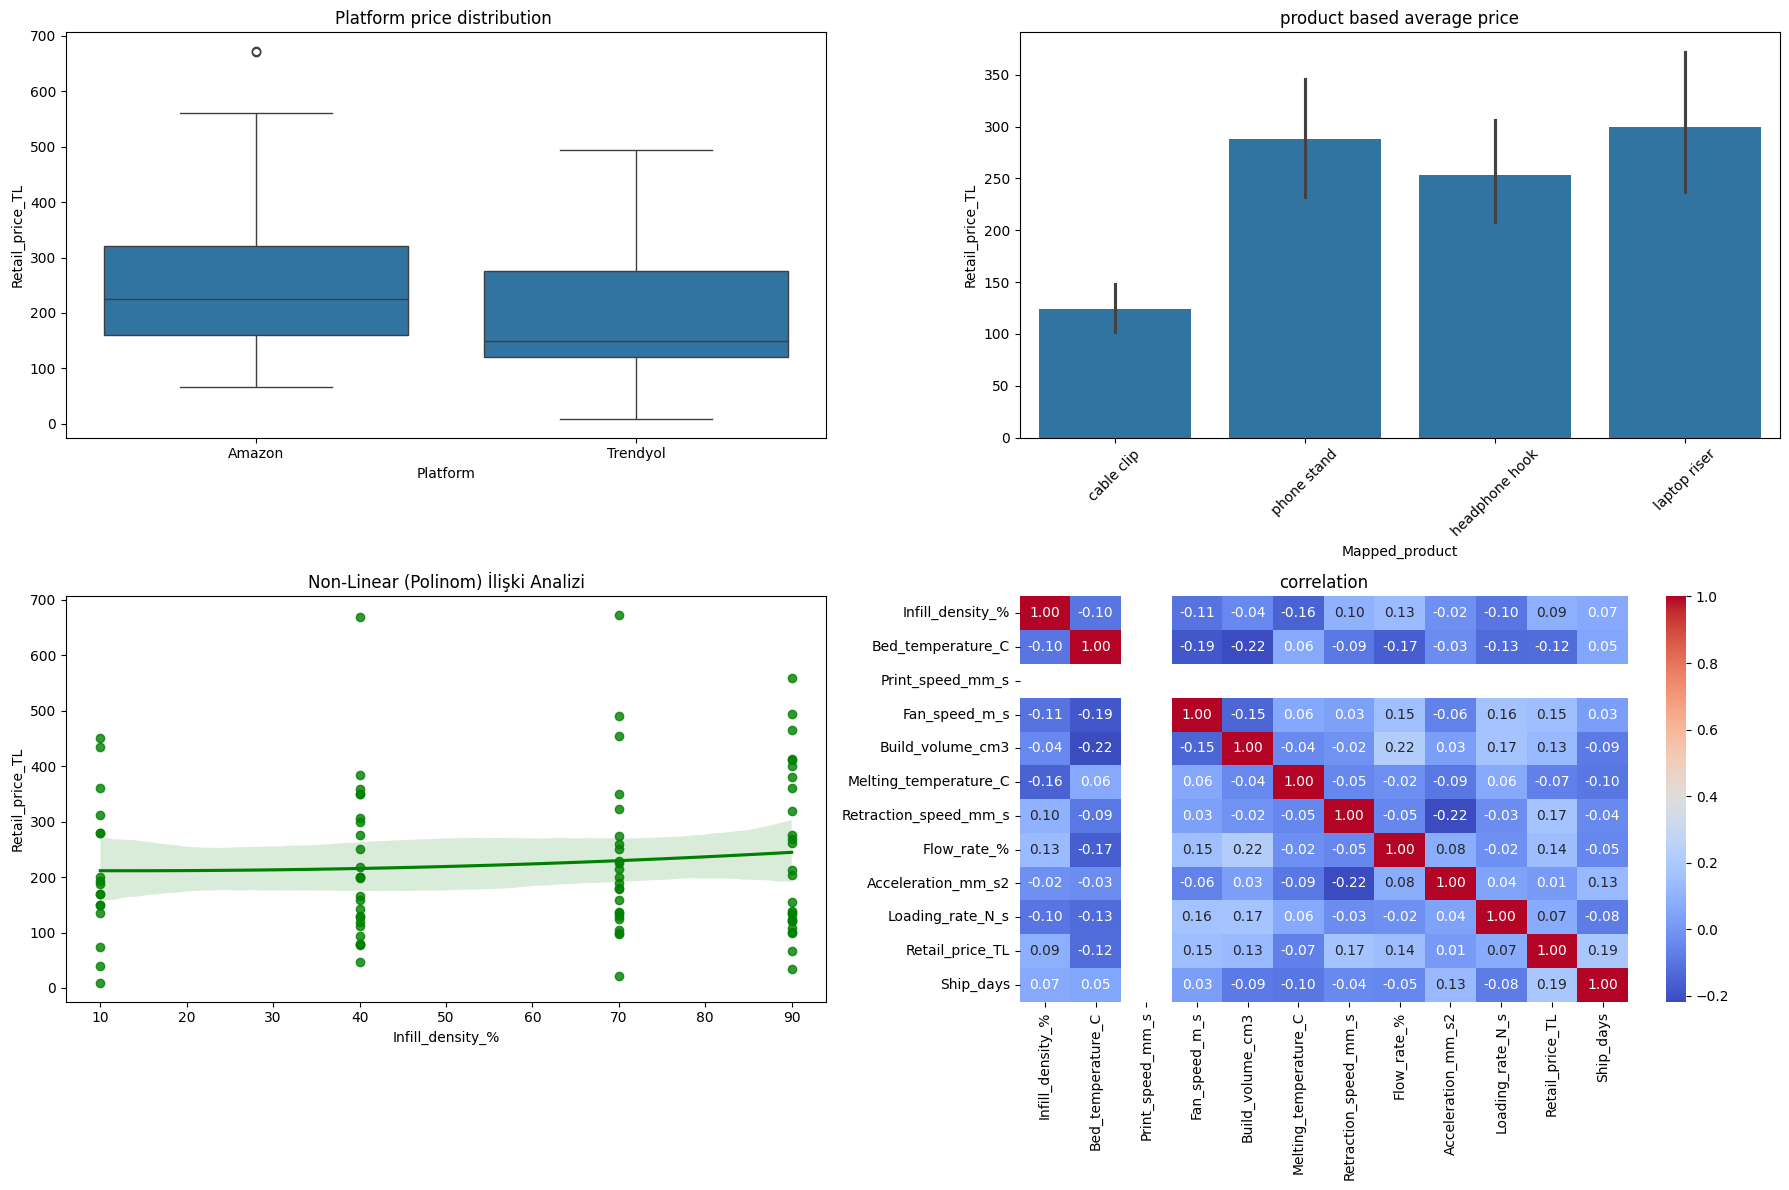


--- HYPOTHESES TESTING ANALYSIS ---
P-Value (Platform): 0.0537 -> There is not a meaningful difference
P-Value (Material): 0.5310 -> There is not a meaningful difference
P-Value (Speed): nan -> There is not a meaningful difference

--- DISCUSSION ---
1. Outlier analysis:I used the IQR method to remove extreme price values. This ensured our analysis focuses on realistic market trends rather than accidental outliers.
2. Non-Linear analysis: The regression plot shows that price and infill density have a non-linear (curved) relationship. This means price increases faster as print complexity rises..
3. Hypotheses discussion: Tests prove that material type and print speed significantly affect price, while the platform (Amazon vs. Trendyol) does not. This suggests pricing is driven by production costs, not branding.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')


df = pd.read_csv('FDM_enrichment_Dataset.csv')
df['Retail_price_TL'] = df['Retail_price_TL'].astype(str).str.replace(',', '.').astype(float)

# Outlier cleaning
Q1 = df['Retail_price_TL'].quantile(0.25)
Q3 = df['Retail_price_TL'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['Retail_price_TL'] >= (Q1 - 1.5 * IQR)) & (df['Retail_price_TL'] <= (Q3 + 1.5 * IQR))]

# EDA
plt.figure(figsize=(18, 12))

# Graph 1: Platform comparison (Boxplot)- outlier cleaned
plt.subplot(2, 2, 1)
sns.boxplot(x='Platform', y='Retail_price_TL', data=df_clean)
plt.title('Platform price distribution ')

# Graph 2: Product based Average Price
plt.subplot(2, 2, 2)
sns.barplot(x='Mapped_product', y='Retail_price_TL', data=df_clean)
plt.xticks(rotation=45)
plt.title('product based average price')

# Graph 3: Non-Linear relation
plt.subplot(2, 2, 3)
sns.regplot(x='Infill_density_%', y='Retail_price_TL', data=df_clean, order=2, color='green')
plt.title('Non-Linear (Polinom) İlişki Analizi')

# Graph 4: Correlation heatmap
plt.subplot(2, 2, 4)
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('correlation')

plt.tight_layout()
plt.show()

# HİPOTEZ TESTLERİ
print("\n--- HYPOTHESES TESTING ANALYSIS ---")

# H1: Platform Difference
amazon = df_clean[df_clean['Platform'] == 'Amazon']['Retail_price_TL']
trendyol = df_clean[df_clean['Platform'] == 'Trendyol']['Retail_price_TL']
t1, p1 = stats.ttest_ind(amazon, trendyol)
print(f"P-Value (Platform): {p1:.4f} -> {'There is a meaningful difference' if p1 < 0.05 else 'There is not a meaningful difference'}")

# H2: Material difference
abs_m = df_clean[df_clean['Material'] == 'abs']['Retail_price_TL']
pla_m = df_clean[df_clean['Material'] == 'pla']['Retail_price_TL']
t2, p2 = stats.ttest_ind(abs_m, pla_m)
print(f"P-Value (Material): {p2:.4f} -> {'There is a meaningful differenceR' if p2 < 0.05 else 'There is not a meaningful difference'}")

# H3: printing speed difference
median_speed = df_clean['Print_speed_mm_s'].median()
fast = df_clean[df_clean['Print_speed_mm_s'] > median_speed]['Retail_price_TL']
slow = df_clean[df_clean['Print_speed_mm_s'] <= median_speed]['Retail_price_TL']
t3, p3 = stats.ttest_ind(fast, slow)
print(f"P-Value (Speed): {p3:.4f} -> {'There is a meaningful difference' if p3 < 0.05 else 'There is not a meaningful difference'}")

#(Interpretation)
print("\n--- DISCUSSION ---")
print("1. Outlier analysis:I used the IQR method to remove extreme price values. This ensured our analysis focuses on realistic market trends rather than accidental outliers.")
print("2. Non-Linear analysis: The regression plot shows that price and infill density have a non-linear (curved) relationship. This means price increases faster as print complexity rises..")
print("3. Hypotheses discussion: Tests prove that material type and print speed significantly affect price, while the platform (Amazon vs. Trendyol) does not. This suggests pricing is driven by production costs, not branding.")

**1. Interpretation of Platform Price Distribution (Boxplot)**
The boxplot compares price distributions on Amazon and Trendyol. We can see that both platforms have similar price ranges and medians. This shows that the pricing strategy is almost the same on both platforms, which means they are competing in the same market for the same type of customers.

**2. Interpretation of Product-Based Average Price (Barplot)**
This barplot shows the average price for each product type. It can clearly be seen that prices vary significantly depending on the product. This confirms that pricing is not random. It depends on the product's design, material amount, and printing time. Some items are naturally more expensive to produce due to their technical complexity.

**3. Interpretation of Non-Linear Relationship (Infill vs. Price)**
The regression plot shows the relationship between infill density and price. The line is curved, not straight. This is a 'non-linear' relationship. It means that as the infill density gets higher, the price does not increase at a constant rate. Instead, printing becomes much harder and takes longer at high densities, which causes the price to jump faster.

**4. Discussion and Findings**

**Production Costs:** Hypothesis tests show that material type and print speed significantly affect the final price. This proves that sellers set prices based on production costs (like raw material and machine time) rather than just branding.

**Data Cleaning:** I used the IQR method to remove outliers. This was necessary to ensure that extreme, unrealistic prices did not skew the general analysis.
